In [1]:
import importlib
import sys
import warnings
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure project root is on sys.path
_project_root = str(
    next(
        (
            _p
            for _p in (Path.cwd(), *Path.cwd().parents)
            if (_p / "common.py").is_file()
        ),
        Path.cwd().parent,
    )
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

warnings.filterwarnings("ignore")

import training_configuration

importlib.reload(training_configuration)

import figure_config

importlib.reload(figure_config)
# Import barplot helpers
import barplots
from figure_config import (
    AXIS_SPINE_COLOR,
    AXIS_SPINE_LINEWIDTH,
    CONTEXT_COLORS,
    CONTEXT_COLORS_RAW,
    EMBEDDING_COLORS,
    FONTSIZE,
    LW_MEDIUM,
    LW_THICK,
    LW_THIN,
    MODEL_COLORS,
    MODEL_LABELS,
    build_barplot_legend,
    configure_axis_spines,
)

importlib.reload(barplots)
from barplots import (
    load_figure_data,
    render_model_comparison,
    render_nhidden_trainval,
)

# Import embedding helpers
from embeddings import (
    load_embedding_data,
    load_marker_data,
    prepare_pca_embeddings,
)

from cell_line_annotations import load_marcotte_subtypes
from common import evaluations_dir, subtypes_tognetti
from embedding_utils import evaluate_luminal_basal_classifier

print("All imports OK")


All imports OK


## Panel helper functions

In [2]:
# ── Shared data loading ──────────────────────────────────────────────────

def load_all_figure_data():
    """Load all DataFrames and embeddings needed by every panel."""
    df_fig1a = load_figure_data("figure1a")
    df_fig3 = load_figure_data("figure3")
    df_fig2 = load_figure_data("figure2")

    # the "all" CV split also carries the 5 held-out test cell lines
    # (common.test_samples); restrict to the 58 training lines
    embedding_df = load_embedding_data(figure="figure1a", dataset="train")
    subtypes_df = load_marcotte_subtypes(embedding_df.cell_line.unique())
    pca_embedding_df = prepare_pca_embeddings(embedding_df, subtypes_df)

    return df_fig1a, df_fig3, df_fig2, pca_embedding_df


def load_trajectory_data(
    model="EGFR_MAPK__logobs_tegfr_aggavg",
    dataset="dream_cytof",
    figure="figure1a",
    context="cytof_init",
):
    """Load and pre-filter DMM trajectory CSV for simulation overlays."""
    traj_path = evaluations_dir / model / dataset / f"trajectories_{figure}.csv"
    traj_df = pd.read_csv(traj_path, index_col=0)
    traj_df = traj_df[
        (traj_df["ref"] == "DMM") & (traj_df["context"] == context)
    ].copy()
    return traj_df


# Colours matching embeddings_parameters notebook
_BIN_COLORS = {"Low": "#2166AC", "High": "#B2182B"}
_SIM_COLORS = {"Low": "#6BAED6", "High": "#FC9272"}


# ── Panel renderers (axis-level) ────────────────────────────────────────

def plot_panel_embeddings(ax, pca_embedding_df, model, context, *, title,
                          show_ylabel=True, show_legend=False, s=30):
    """Plot PCA embedding scatter on *ax*, coloured by luminal/basal."""
    plot_df = pca_embedding_df[
        (pca_embedding_df["model"] == model)
        & (pca_embedding_df["context"] == context)
    ].copy()
    for lb, c in EMBEDDING_COLORS.items():
        m = plot_df["luminalbasal"] == lb
        ax.scatter(plot_df.loc[m, "L1"], plot_df.loc[m, "L2"],
                   c=c, label=lb, s=s, edgecolors="black", linewidths=LW_THIN)

    # Zero-centred symmetric limits & axes at origin
    x_max = max(abs(plot_df["L1"].min()), abs(plot_df["L1"].max()))
    y_max = max(abs(plot_df["L2"].min()), abs(plot_df["L2"].max()))
    ax.set_xlim(-x_max * 1.1, x_max * 1.1)
    ax.set_ylim(-y_max * 1.1, y_max * 1.1)
    ax.axhline(0, color=AXIS_SPINE_COLOR, linewidth=AXIS_SPINE_LINEWIDTH, zorder=0)
    ax.axvline(0, color=AXIS_SPINE_COLOR, linewidth=AXIS_SPINE_LINEWIDTH, zorder=0)
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)
    ax.grid(False)

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2" if show_ylabel else "")
    ax.set_title(title)
    if show_legend:
        ax.legend(frameon=False, fontsize=8)


def plot_panel_classification(ax, merged_e, *, title="Subtype Classification",
                              xlabel_color=None, ylabel_color=None):
    """Plot luminal/basal classification scatter (base vs tEGFR/fEGFR ROC AUC)."""
    _contexts = merged_e["context"].unique().tolist()
    _palette = {ctx: CONTEXT_COLORS_RAW.get(ctx, "#333333") for ctx in _contexts}
    _MARKER_SIZE = 50
    sns.scatterplot(
        data=merged_e, x="base", y="tegfr",
        hue="context", style="classifier",
        palette=_palette,
        s=_MARKER_SIZE, edgecolor="black", linewidth=LW_THIN, ax=ax,
    )
    # Overlay fEGFR points (cytof_init_plus_tEGFR, paired to cytof_init base)
    if "fegfr" in merged_e.columns:
        _fegfr_sub = merged_e[merged_e["context"] == "cytof_init"].dropna(subset=["fegfr"])
        if not _fegfr_sub.empty:
            _fegfr_color = MODEL_COLORS.get("DMM + EGFR est", "#7f7f7f")
            _clf_markers = {c: m for c, m in zip(
                merged_e["classifier"].unique(), ["o", "X", "s", "P", "D"]
            )}
            for _clf, _s in _fegfr_sub.groupby("classifier"):
                ax.scatter(
                    _s["base"], _s["fegfr"],
                    marker=_clf_markers.get(_clf, "D"),
                    s=_MARKER_SIZE, color=_fegfr_color,
                    edgecolor="black", linewidth=LW_THIN, zorder=5,
                )
    ax.plot([0.45, 1.05], [0.45, 1.05], ls="--", color="grey", lw=LW_MEDIUM, zorder=0)
    ax.set(xlim=(0.45, 1.05), ylim=(0.45, 1.05))
    _ticks = np.arange(0.5, 1.05, 0.1)
    ax.set_xticks(_ticks); ax.set_yticks(_ticks)
    ax.set_xlabel("AUROC (baseline)",color=xlabel_color or "black")
    ax.set_ylabel("AUROC (mech. int.)", color=ylabel_color or "black")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    # Classifiers in legend + fEGFR model colour patch
    from matplotlib.patches import Patch as _Patch
    full_leg = ax.get_legend()
    classifiers = merged_e["classifier"].unique().tolist()
    _h, _l = ax.get_legend_handles_labels()
    clf_h = [h for h, l in zip(_h, _l) if l in classifiers]
    clf_l = [l for l in _l if l in classifiers]
    if full_leg:
        full_leg.remove()
    ax.legend(clf_h, clf_l, frameon=False, fontsize=FONTSIZE, loc="lower right")
    configure_axis_spines(ax)
    ax.grid(False)


import numpy as np


def plot_panel_binned_cytof(ax, pca_embedding_df, *, bin_labels=("Low", "High"),
                            sim_df=None):
    """Plot pERK dynamics binned by EGFR transcripts on *ax*.

    If *sim_df* is provided (pre-filtered to ref=DMM, context=cytof_init),
    model simulations are averaged over seeds per cell line then per bin and
    overlaid as dashed lines.  Simulation timepoints are restricted to those
    present in the experimental data.  Colours follow the same scheme as the
    embeddings_parameters notebook (_BIN_COLORS / _SIM_COLORS).
    """
    from embeddings import load_dynamic_cytof_data, load_marker_data, get_cytof_marker_label

    emb = pca_embedding_df[
        (pca_embedding_df["model"] == "EGFR_MAPK__logobs_tegfr_aggavg")
        & (pca_embedding_df["context"] == "cytof_init")
    ].copy()
    marker_values = load_marker_data("EGFR", "transcriptomics")
    # Split at the mean of the EGFR transcript level, matching
    # plot_binned_param_dynamics in figure_3. NaN <= mean is False, which would
    # quietly file cell lines lacking the marker under "High", so those are left
    # unbinned and drop out at the merge below.
    _egfr = pd.Series(
        np.asarray(emb.index.map(marker_values), dtype=float), index=emb.index
    )
    _thr = _egfr.mean()
    emb["bin"] = pd.Categorical(
        pd.Series(
            np.where(_egfr <= _thr, bin_labels[0], bin_labels[1]), index=emb.index
        ).where(_egfr.notna()),
        categories=list(bin_labels),
        ordered=True,
    )
    print(
        f"EGFR transcript mean split at {_thr:.4g}: "
        f"{int((_egfr <= _thr).sum())} {bin_labels[0]} / "
        f"{int((_egfr > _thr).sum())} {bin_labels[1]}"
        + (f", {int(_egfr.isna().sum())} unbinned" if _egfr.isna().any() else "")
    )
    cell_bins = emb[["bin"]].reset_index()
    cell_bins.columns = ["cell_line", "bin"]
    bin_counts = cell_bins["bin"].value_counts()

    dynamic_data = load_dynamic_cytof_data("p.ERK", "EGF")
    merged = dynamic_data.merge(cell_bins, on="cell_line", how="inner")
    grouped = merged.groupby(["bin", "time"])["measurement"].agg(
        ["mean", "std", "count"]).reset_index()

    # Experimental timepoints used to restrict simulation output
    exp_times = set(grouped["time"].unique())

    # ── Model simulation overlay ─────────────────────────────────────────
    sim_grouped = None
    if sim_df is not None:
        sim_sub = sim_df[
            (sim_df["observable"] == "pERK_Y204_obs")
            & (sim_df["condition"] == "EGF")
            & (sim_df["time"].isin(exp_times))
        ].copy()
        if not sim_sub.empty:
            # Average over seeds (jobs) per cell line and time
            sim_cl = (
                sim_sub.groupby(["sample", "time"])["sim"]
                .mean()
                .reset_index()
                .rename(columns={"sample": "cell_line"})
            )
            sim_merged = sim_cl.merge(
                cell_bins[["cell_line", "bin"]], on="cell_line", how="inner"
            )
            sim_grouped = (
                sim_merged.groupby(["bin", "time"])["sim"]
                .agg(["mean", "std", "count"])
                .reset_index()
            )

    for bl in bin_labels:
        color = _BIN_COLORS.get(bl, "grey")
        bd = grouped[grouped["bin"] == bl]
        if len(bd) > 0:
            ax.plot(bd["time"], bd["mean"], marker="o", color=color,
                    label=f"{bl} (n={bin_counts.get(bl, 0)})",
                    linewidth=LW_THICK, markersize=4)
            se = bd["std"] / np.sqrt(bd["count"])
            ax.fill_between(bd["time"], bd["mean"] - se, bd["mean"] + se,
                            color=color, alpha=0.2)

    if sim_grouped is not None:
        for bl in bin_labels:
            sim_color = _SIM_COLORS.get(bl, "grey")
            sd = sim_grouped[sim_grouped["bin"] == bl]
            if len(sd) > 0:
                ax.plot(sd["time"], sd["mean"], linestyle="-",
                        color=sim_color, linewidth=LW_MEDIUM,
                        label=f"{bl} (sim)")
                sim_se = sd["std"] / np.sqrt(sd["count"])
                ax.fill_between(sd["time"], sd["mean"] - sim_se, sd["mean"] + sim_se,
                                color=sim_color, alpha=0.12)

    ax.set_xlabel("Time (min)")
    ax.set_ylabel(get_cytof_marker_label("p.ERK"))
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))
    ax.set_title("Cell Lines Binned by EGFR tx")
    ax.legend(frameon=False, fontsize=8)
    configure_axis_spines(ax)


def evaluate_classification(pca_embedding_df):
    """Run luminal/basal classifiers and return merged base-vs-tEGFR/fEGFR DataFrame."""
    models = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]
    model_fegfr = "EGFR_MAPK__logobs_fegfr_aggavg"
    contexts = ["cytof_init", "multimodal"]
    classifiers = ["svm", "logreg", "rf"]
    emb = pca_embedding_df.reset_index()

    all_results = []
    for clf in classifiers:
        res = evaluate_luminal_basal_classifier(
            emb[emb["model"].isin(models) & emb["context"].isin(contexts)],
            subtypes_tognetti,
            classifier=clf,
            group_cols=["context", "model"],
        )
        res["classifier"] = clf
        all_results.append(res)

    results = pd.concat(all_results, ignore_index=True)
    base = results[results["model"] == models[0]][
        ["context", "classifier", "roc_auc"]].rename(columns={"roc_auc": "base"})
    tegfr = results[results["model"] == models[1]][
        ["context", "classifier", "roc_auc"]].rename(columns={"roc_auc": "tegfr"})
    merged = base.merge(tegfr, on=["context", "classifier"])

    # ── fEGFR evaluation (cytof_init_plus_tEGFR → paired with cytof_init base) ──
    # Uses the fegfr model with CyTOF + EGFR tx as feature augmentation input.
    _fegfr_raw = load_embedding_data("figure2", dataset="train")
    _fegfr_raw = _fegfr_raw[
        (_fegfr_raw["model"] == model_fegfr)
        & (_fegfr_raw["context"] == "cytof_init_plus_tEGFR")
    ]
    if not _fegfr_raw.empty:
        _subtypes_df = load_marcotte_subtypes(_fegfr_raw["cell_line"].unique())
        _fegfr_pca = prepare_pca_embeddings(_fegfr_raw, _subtypes_df)
        _fegfr_results = []
        for clf in classifiers:
            res = evaluate_luminal_basal_classifier(
                _fegfr_pca.reset_index(),
                subtypes_tognetti,
                classifier=clf,
                group_cols=["context", "model"],
            )
            res["classifier"] = clf
            _fegfr_results.append(res)
        _fegfr_df = pd.concat(_fegfr_results, ignore_index=True)
        _fegfr_only = (
            _fegfr_df[_fegfr_df["model"] == model_fegfr]
            [["context", "classifier", "roc_auc"]]
            .rename(columns={"roc_auc": "fegfr"})
            # cytof_init_plus_tEGFR is the feature-augmented variant of cytof_init;
            # map back so the merge aligns with the base-model cytof_init rows.
            .assign(context="cytof_init")
        )
        merged = merged.merge(_fegfr_only, on=["context", "classifier"], how="left")

    return merged


print("Helper functions defined")


Helper functions defined


## Load all data

In [3]:
df_fig1a, df_fig3, df_fig2, pca_embedding_df = load_all_figure_data()
merged_e = evaluate_classification(pca_embedding_df)
traj_df = load_trajectory_data()

## Panel A — Base model comparison across data modalities

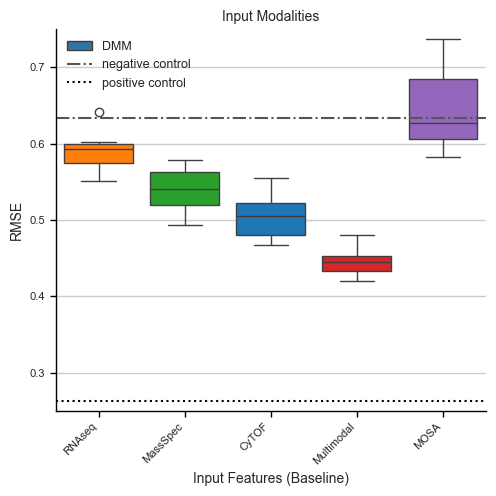

In [4]:
fig_a, ax_a = plt.subplots(figsize=(5, 5))
h_a, l_a = render_model_comparison(
    ax_a, df_fig1a,
    dataset="test", refs=("DMM",), ylim=(0.25, 0.75),
    models=["EGFR_MAPK__logobs"], title="Input Modalities",
)
ax_a.legend(h_a, l_a, frameon=False, fontsize=9)
fig_a.tight_layout()
fig_a.savefig("fig2_panelA.pdf", bbox_inches="tight")
plt.show()

## MOSA diagnostic — train/val vs test

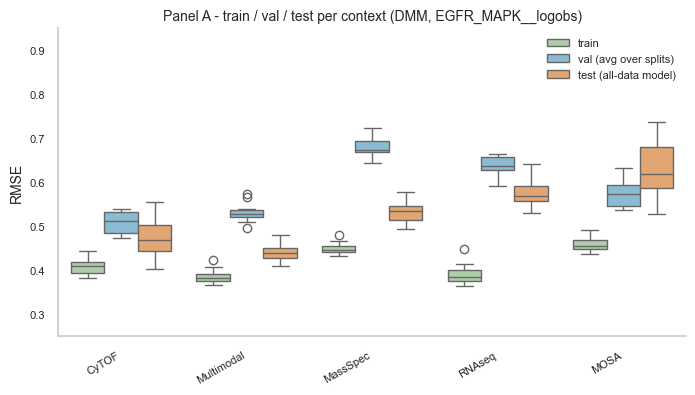

In [5]:

# Build a tidy DataFrame with three "split" levels per context:
#   train = dataset=="train" & samples=="all"  (model trained on all cell lines)
#   val   = dataset=="val" & samples != "all"  (LOOCV-style, averaged over left-out
#           cell lines per job, so variability over seeds/jobs is retained)
#   test  = dataset=="val" & samples == "all"  (model trained on all cell lines)
_dmm = df_fig1a[df_fig1a["ref"] == "DMM"].copy()

_train = (_dmm[(_dmm.dataset == "train") & _dmm.samples.str.startswith("all")]
          .assign(split="train"))
_val   = (_dmm[(_dmm.dataset == "val") & ~_dmm.samples.str.startswith("all")]
          .groupby(["context", "job"], as_index=False)["rmse"].mean()
          .assign(split="val (avg over splits)"))
_test  = (_dmm[(_dmm.dataset == "val") & _dmm.samples.str.startswith("all")]
          .assign(split="test (all-data model)"))
_diag = pd.concat([_train, _val, _test], ignore_index=True)

_context_order = ["cytof_init", "multimodal", "proteomics", "transcriptomics", "MOSA"]
_context_labels = {
    "cytof_init": "CyTOF", "multimodal": "Multimodal",
    "proteomics": "MassSpec", "transcriptomics": "RNAseq", "MOSA": "MOSA",
}
_diag["context_label"] = _diag["context"].map(_context_labels)
_label_order = [_context_labels[c] for c in _context_order if c in _diag["context"].unique()]

_hue_order = ["train", "val (avg over splits)", "test (all-data model)"]
_palette = {
    "train":                  "#a8d5a2",
    "val (avg over splits)":  "#7fbfdf",
    "test (all-data model)":  "#f4a460",
}

fig_diag, ax_diag = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=_diag, x="context_label", y="rmse",
    hue="split", order=_label_order,
    hue_order=_hue_order, palette=_palette,
    ax=ax_diag,
)
ax_diag.set_xlabel("")
ax_diag.set_ylabel("RMSE")
ax_diag.set_ylim(0.25, 0.95)
ax_diag.set_title("Panel A - train / val / test per context (DMM, EGFR_MAPK__logobs)")
ax_diag.set_xticklabels(ax_diag.get_xticklabels(), rotation=30, ha="right")
ax_diag.legend(frameon=False, fontsize=8)
sns.despine(ax=ax_diag)
ax_diag.grid(False)
fig_diag.tight_layout()
plt.show()


## Panel B — t/pRTK mechanistic integrations

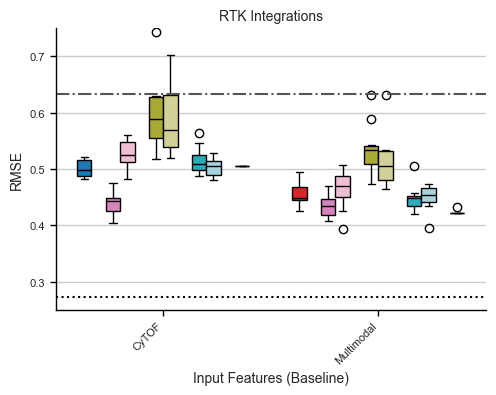

In [6]:
fig_b, ax_b = plt.subplots(figsize=(5, 4))
render_model_comparison(
    ax_b, df_fig3,
    dataset="test", refs=("DMM", "elasticnet"), ylim=(0.25, 0.75),
    title="RTK Integrations",
)
fig_b.tight_layout()
fig_b.savefig("fig2_panelB.pdf", bbox_inches="tight")
plt.show()

## Panel C — Feature augmentations (t/pRTKs, luminal/basal)

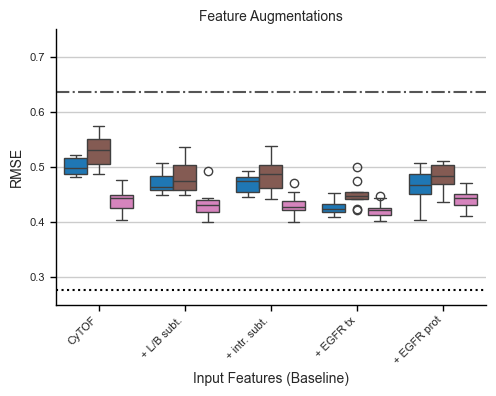

In [7]:
fig_c, ax_c = plt.subplots(figsize=(5, 4))
render_model_comparison(
    ax_c, df_fig2,
    dataset="test", refs=("DMM",), ylim=(0.25, 0.75),
    models=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_tegfr_aggavg"],
    title="Feature Augmentations",
    group_padding=False,
)
fig_c.tight_layout()
fig_c.savefig("fig2_panelC.pdf", bbox_inches="tight")
plt.show()

## Panel D — Latent embeddings (multimodal base & CyTOF + tEGFR)

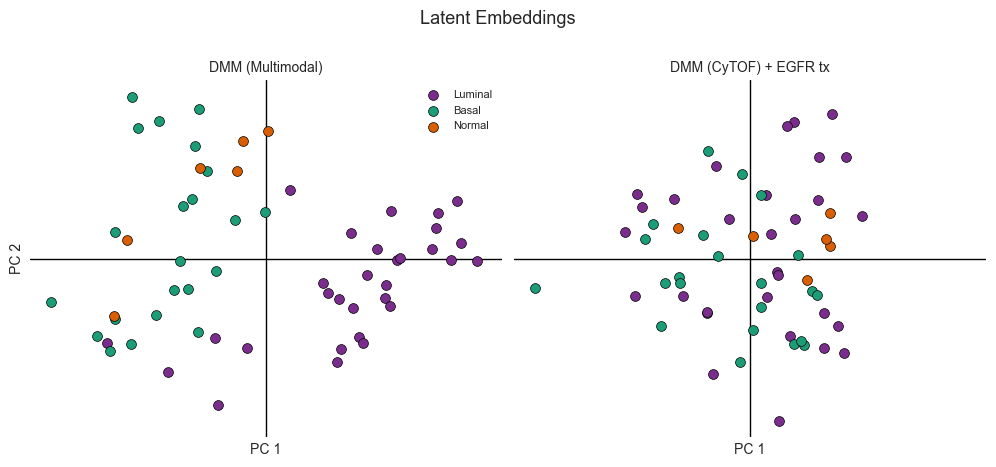

In [8]:
fig_d, axes_d = plt.subplots(1, 2, figsize=(10, 4.5))

configs_d = [
    ("EGFR_MAPK__logobs", "multimodal", "DMM (Multimodal)"),
    ("EGFR_MAPK__logobs_tegfr_aggavg", "cytof_init", "DMM (CyTOF) + EGFR tx"),
]

for i, (model, context, title) in enumerate(configs_d):
    plot_panel_embeddings(
        axes_d[i], pca_embedding_df, model, context,
        title=title, show_ylabel=(i == 0), show_legend=(i == 0), s=50,
    )

fig_d.suptitle("Latent Embeddings", fontsize=13, y=1.02)
fig_d.tight_layout()
fig_d.savefig("fig2_panelD.pdf", bbox_inches="tight")
plt.show()

## Panel E — Luminal/Basal classification accuracy scatter

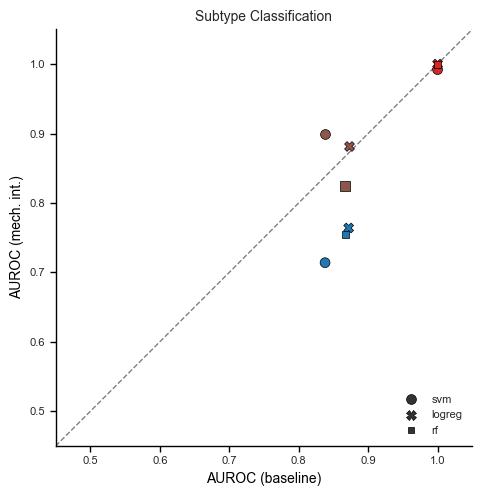

In [9]:
fig_e, ax_e = plt.subplots(figsize=(5, 5))
plot_panel_classification(ax_e, merged_e, title="Subtype Classification")
fig_e.tight_layout()
fig_e.savefig("fig2_panelE.pdf", bbox_inches="tight")
plt.show()

## Panel F — Binned dynamic CyTOF (EGFR transcripts, pERK, EGF only)

EGFR transcript mean split at 2.675: 24 Low / 34 High


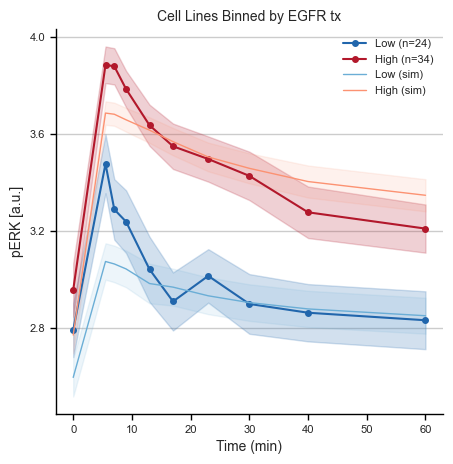

In [10]:
fig_f, ax_f = plt.subplots(figsize=(5, 5))
plot_panel_binned_cytof(ax_f, pca_embedding_df, sim_df=traj_df)
fig_f.savefig("fig2_panelF.pdf", bbox_inches="tight")
plt.show()

## Panel G — n_hidden scan: train vs val (base vs tEGFR)

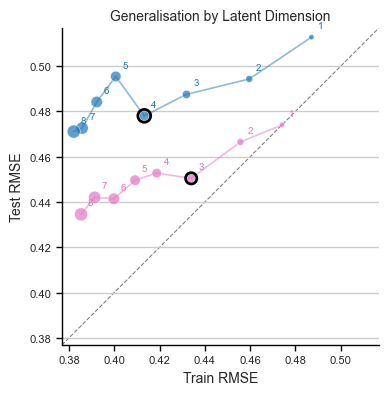

In [11]:
fig_g, ax_g = plt.subplots(figsize=(5, 4))
render_nhidden_trainval(
    ax_g,
    models=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    highlights={"EGFR_MAPK__logobs": (4,), "EGFR_MAPK__logobs_tegfr_aggavg": (3,)},
    annotate_nh=True, max_nhidden=8,
    title="Generalisation by Latent Dimension", ylabel="Test RMSE",
)
fig_g.tight_layout()
fig_g.savefig("fig2_panelG.pdf", bbox_inches="tight")
plt.show()

## Composite Figure 2

EGFR transcript mean split at 2.675: 24 Low / 34 High


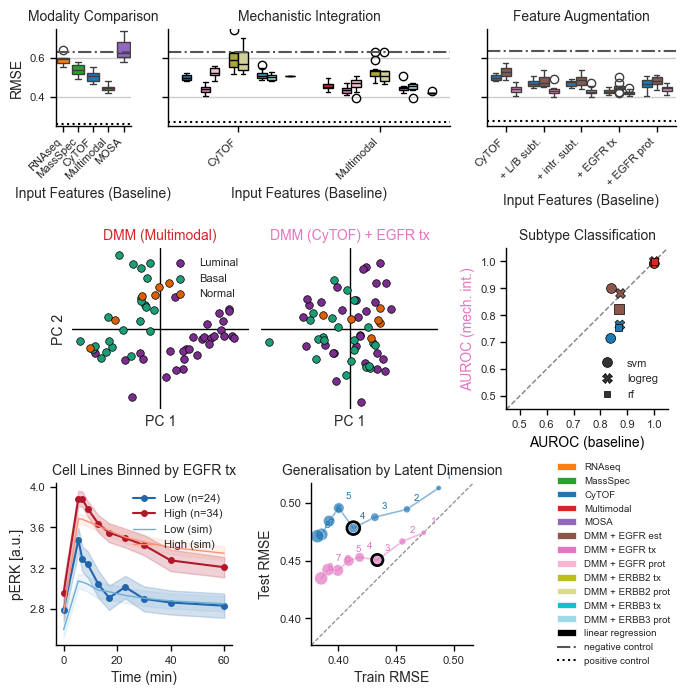

Figure 2 saved.


In [12]:
# ---------------------------------------------------------------------------
# Assemble all panels into a single composite figure
# Layout (3 rows):
#   Row 1:  A (modalities)   |  B (RTK)                  |  C (augmentations)
#   Row 2:  D-left (emb MM)  |  D-right (emb CyTOF+tEGFR)|  E (scatter)
#   Row 3:  F (binned cytof) |  G (n_hidden scan)        |  (legend)
# ---------------------------------------------------------------------------

fig = plt.figure(figsize=(8, 8))

# Outer grid: 3 rows (row 1 barplots, row 2 embeddings, row 3 cytof+nhidden)
gs_outer = gridspec.GridSpec(
    3, 1, figure=fig,
    height_ratios=[0.6, 1, 1],
    hspace=0.7,
)

# Row 1: custom width ratios — narrower Panel A
gs_row1 = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=gs_outer[0],
    width_ratios=[0.4, 1.5, 1], wspace=0.2,
)

# Rows 2 & 3: equal-width columns
gs_row2 = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=gs_outer[1],
    width_ratios=[1, 1, 1], wspace=0.25,
)
gs_row3 = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=gs_outer[2],
    width_ratios=[1, 1, 0.7], wspace=0.45,
)

# Keep gs as an alias for rows 2/3 position lookups
gs = None  # no longer used directly
_row_shift = 0.03

# ── Row 1: barplot panels ──────────────────────────────────────
ax_A = fig.add_subplot(gs_row1[0, 0])
h_A, l_A = render_model_comparison(
    ax_A, df_fig1a,
    dataset="test", refs=("DMM",), ylim=(0.25, 0.75),
    models=["EGFR_MAPK__logobs"], title="Modality Comparison",
)

ax_B = fig.add_subplot(gs_row1[0, 1])
h_B, l_B = render_model_comparison(
    ax_B, df_fig3,
    dataset="test", refs=("DMM", "elasticnet"), ylim=(0.25, 0.75),
    title="Mechanistic Integration", ylabel="",
)
ax_B.set_yticklabels([])

ax_C = fig.add_subplot(gs_row1[0, 2])
h_C, l_C = render_model_comparison(
    ax_C, df_fig2,
    dataset="test", refs=("DMM",), ylim=(0.25, 0.75),
    models=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_tegfr_aggavg"],
    title="Feature Augmentation", ylabel="",
    group_padding=False,
)
ax_C.set_yticklabels([])

# ── Row 2: embeddings + classification scatter ─────────────────
ax_D1 = fig.add_subplot(gs_row2[0, 0])
plot_panel_embeddings(ax_D1, pca_embedding_df,
                      "EGFR_MAPK__logobs_tegfr_aggavg", "multimodal",
                      title="Multimodal", show_legend=True)
ax_D1.set_title("DMM (Multimodal)", color=CONTEXT_COLORS["Multimodal"])

ax_D2 = fig.add_subplot(gs_row2[0, 1])
plot_panel_embeddings(ax_D2, pca_embedding_df,
                      "EGFR_MAPK__logobs_tegfr_aggavg", "cytof_init",
                      title="CyTOF + EGFR tx", show_ylabel=False)
ax_D2.set_title("DMM (CyTOF) + EGFR tx", color=MODEL_COLORS[MODEL_LABELS.get("EGFR_MAPK__logobs_tegfr_aggavg")])

ax_E = fig.add_subplot(gs_row2[0, 2])
plot_panel_classification(ax_E, merged_e,
                          ylabel_color=MODEL_COLORS.get(
                              MODEL_LABELS.get("EGFR_MAPK__logobs_tegfr_aggavg", ""), "black"))

# ── Row 3: binned cytof + n_hidden + legend ────────────────────
ax_F = fig.add_subplot(gs_row3[0, 0])
plot_panel_binned_cytof(ax_F, pca_embedding_df, sim_df=traj_df)
ax_F.grid(False)

ax_G = fig.add_subplot(gs_row3[0, 1])
render_nhidden_trainval(
    ax_G,
    models=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    highlights={"EGFR_MAPK__logobs": (4,), "EGFR_MAPK__logobs_tegfr_aggavg": (3,)},
    annotate_nh=True, max_nhidden=8,
    title="Generalisation by Latent Dimension", ylabel="Test RMSE",
)
ax_G.set_xticks([0.40, 0.45, 0.50])
ax_G.set_yticks([0.40, 0.45, 0.50])
ax_G.grid(False)

# ── Shared legend ──────────────────────────────────────────────
_all_contexts = list(dict.fromkeys(
    [t.get_text() for t in ax_A.get_xticklabels()]
    + [t.get_text() for t in ax_B.get_xticklabels()]
))
_all_models = list(dict.fromkeys(
    lb for lb in list(l_C) + list(l_B)
    if lb not in ("DMM", "negative control", "positive control", "")
))
# Ensure "linear regression" comes last among model entries
if "linear regression" in _all_models:
    _all_models.remove("linear regression")
    _all_models.append("linear regression")
leg_h, leg_l = build_barplot_legend(_all_contexts, _all_models, include_refs=True)

ax_leg = fig.add_subplot(gs_row3[0, 2])
ax_leg.axis("off")
ax_leg.legend(leg_h, leg_l, loc="center", frameon=False, fontsize=7)

# ── Adjust row spacing ────────────────────────────────────────
for ax in [ax_A, ax_B, ax_C]:
    bb = ax.get_position()
    ax.set_position([bb.x0, bb.y0 + _row_shift, bb.width, bb.height])
for ax in [ax_F, ax_G, ax_leg]:
    bb = ax.get_position()
    ax.set_position([bb.x0, bb.y0 + _row_shift, bb.width, bb.height])

fig.canvas.draw()

_pos_E = ax_E.get_position()
for _ax in [ax_D1, ax_D2]:
    _pos = _ax.get_position()
    _ax.set_position([_pos.x0, _pos_E.y0, _pos.width, _pos_E.height])

# Nudge D1 and D2 closer together (shift D1 right, D2 left)
_emb_shift = 0.02
_pos_D1 = ax_D1.get_position()
ax_D1.set_position([_pos_D1.x0 + _emb_shift, _pos_D1.y0, _pos_D1.width, _pos_D1.height])
_pos_D2 = ax_D2.get_position()
ax_D2.set_position([_pos_D2.x0 - _emb_shift, _pos_D2.y0, _pos_D2.width, _pos_D2.height])

_pos_G = ax_G.get_position()
for _ax in [ax_F, ax_leg]:
    _pos = _ax.get_position()
    _ax.set_position([_pos.x0, _pos_G.y0, _pos.width, _pos_G.height])

fig.savefig("Figure2_composite.pdf", dpi=300, bbox_inches="tight")
fig.savefig("Figure2_composite.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")


In [13]:
# Text-ready summary statistics

import pandas as pd

MODEL_BASE = "EGFR_MAPK__logobs"
MODEL_TEGFR = "EGFR_MAPK__logobs_tegfr_aggavg"


def _pretty_context(ctx: str) -> str:
    mapping = {
        "cytof_init": "CyTOF",
        "multimodal": "Multimodal",
        "transcriptomics": "RNAseq",
        "proteomics": "MassSpec",
        "cytof_init_plus_lb": "+ LB subtype",
        "cytof_init_plus_intr": "+ int. subtype",
        "cytof_init_plus_tEGFR": "+ EGFR tx",
        "cytof_init_plus_pEGFR": "+ EGFR prot",
    }
    return mapping.get(ctx, str(ctx))


def _pick_dataset(df: pd.DataFrame) -> str | None:
    if "dataset" not in df.columns:
        return None
    ds = set(df["dataset"].dropna().astype(str).unique())
    for candidate in ("test", "val", "train"):
        if candidate in ds:
            return candidate
    return None


def _rmse_by_context(df: pd.DataFrame, model: str) -> pd.Series:
    required = {"model", "context", "dataset", "rmse"}
    if not required.issubset(df.columns):
        return pd.Series(dtype=float)

    dataset_used = _pick_dataset(df)
    if dataset_used is None:
        return pd.Series(dtype=float)

    rows = df[(df["model"] == model) & (df["dataset"] == dataset_used)].copy()
    if rows.empty:
        return pd.Series(dtype=float)

    out = rows.groupby("context", observed=True)["rmse"].mean().sort_index()
    out.index = [_pretty_context(c) for c in out.index]
    return out


print("=== Text Statistics (Figure 2) ===")

# 1) Context-specific DMM performance values
dmm_context_perf = _rmse_by_context(df_fig1a, MODEL_BASE)
print("\nContext-specific performance values (DMM RMSE):")
if dmm_context_perf.empty:
    print("  n/a")
else:
    for context_name, value in dmm_context_perf.items():
        print(f"  {context_name}: {value:.4f}")

# 2) tEGFR model performance values across available contexts
frames_with_rmse = []
for frame_name in ["df_fig1a", "df_fig2", "df_fig3"]:
    frame = globals().get(frame_name)
    if isinstance(frame, pd.DataFrame):
        s = _rmse_by_context(frame, MODEL_TEGFR)
        if not s.empty:
            frames_with_rmse.append(s)

print("\ntEGFR model performance (RMSE):")
if not frames_with_rmse:
    print("  n/a")
    tegfr_perf = pd.Series(dtype=float)
else:
    tegfr_perf = pd.concat(frames_with_rmse, axis=1).mean(axis=1).sort_index()
    for context_name, value in tegfr_perf.items():
        print(f"  {context_name}: {value:.4f}")

# 2b) delta RMSE for tEGFR vs DMM on shared contexts (matches sections 1+2)
print("\nΔRMSE (tEGFR - DMM) on shared contexts:")
if dmm_context_perf.empty or tegfr_perf.empty:
    print("  n/a")
else:
    shared = dmm_context_perf.to_frame("dmm").join(tegfr_perf.to_frame("tegfr"), how="inner")
    if shared.empty:
        print("  n/a")
    else:
        shared["delta_rmse"] = shared["tegfr"] - shared["dmm"]
        shared["improvement"] = shared["dmm"] - shared["tegfr"]
        for context_name, row in shared.sort_index().iterrows():
            print(
                f"  {context_name}: Δ={row['delta_rmse']:+.4f} "
                f"(improvement={row['improvement']:.4f})"
            )

# 3) Counts for luminal vs basal for the two embedding panels
print("\nCounts for luminal vs basal:")
if {"model", "context", "luminalbasal"}.issubset(pca_embedding_df.columns):
    subsets = [
        ("DMM (Multimodal)", MODEL_BASE, "multimodal"),
        ("DMM (CyTOF) + EGFR tx", MODEL_TEGFR, "cytof_init"),
    ]
    for title, model, context in subsets:
        sub = pca_embedding_df[
            (pca_embedding_df["model"] == model)
            & (pca_embedding_df["context"] == context)
        ]
        c = (
            sub["luminalbasal"]
            .replace({"basl": "basal", "Basl": "basal", "Lum": "luminal"})
            .astype(str)
            .str.lower()
            .value_counts()
        )
        luminal_n = int(c.get("luminal", 0))
        basal_n = int(c.get("basal", 0))
        print(f"  {title}: luminal={luminal_n}, basal={basal_n}")
else:
    print("  n/a")

# 4) AUROC levels and delta for CyTOF/Multimodal
print("\nAUROC by context (DMM vs tEGFR):")
if {"context", "classifier", "base", "tegfr"}.issubset(merged_e.columns):
    delta = merged_e.copy()
    delta["delta_auroc"] = delta["tegfr"] - delta["base"]

    for ctx in ["cytof_init", "multimodal"]:
        chunk = delta[delta["context"] == ctx]
        if chunk.empty:
            continue
        base_mean = chunk["base"].mean()
        tegfr_mean = chunk["tegfr"].mean()
        mean_val = chunk["delta_auroc"].mean()
        std_val = chunk["delta_auroc"].std(ddof=1) if len(chunk) > 1 else 0.0

        print(f"  {_pretty_context(ctx)}: DMM={base_mean:.4f}, tEGFR={tegfr_mean:.4f}, Δ={mean_val:+.4f} (sd={std_val:.4f})")
        for _, row in chunk.sort_values("classifier").iterrows():
            print(
                f"    {row['classifier']}: DMM={row['base']:.3f}, "
                f"tEGFR={row['tegfr']:.3f}, Δ={row['delta_auroc']:+.3f}"
            )
else:
    print("  n/a")

=== Text Statistics (Figure 2) ===

Context-specific performance values (DMM RMSE):
  MOSA: 0.6094
  CyTOF: 0.5456
  Multimodal: 0.5352
  MassSpec: 0.6607
  RNAseq: 0.6314

tEGFR model performance (RMSE):
  + EGFR prot: 0.4494
  + EGFR tx: 0.4203
  + LB subtype: 0.4386
  + int. subtype: 0.4329
  CyTOF: 0.4680
  MOSA: 0.5976
  MassSpec: 0.6615
  Multimodal: 0.4805
  RNAseq: 0.6285

ΔRMSE (tEGFR - DMM) on shared contexts:
  CyTOF: Δ=-0.0776 (improvement=0.0776)
  MOSA: Δ=-0.0118 (improvement=0.0118)
  MassSpec: Δ=+0.0008 (improvement=-0.0008)
  Multimodal: Δ=-0.0547 (improvement=0.0547)
  RNAseq: Δ=-0.0029 (improvement=0.0029)

Counts for luminal vs basal:
  DMM (Multimodal): luminal=30, basal=22
  DMM (CyTOF) + EGFR tx: luminal=30, basal=22

AUROC by context (DMM vs tEGFR):
  CyTOF: DMM=0.8590, tEGFR=0.7440, Δ=-0.1150 (sd=0.0082)
    logreg: DMM=0.872, tEGFR=0.764, Δ=-0.108
    rf: DMM=0.867, tEGFR=0.754, Δ=-0.113
    svm: DMM=0.838, tEGFR=0.714, Δ=-0.124
  Multimodal: DMM=1.0000, tEGFR

## EGFR transcription × CyTOF PCA embedding correlation

cytof_dynamic: matrix (63, 137), using 20 PCs


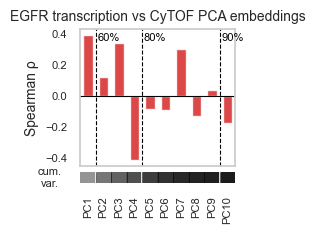

In [14]:
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
import matplotlib.gridspec as gridspec
from matplotlib.transforms import blended_transform_factory as _btf
from dmm.config_options import Conf
from dmm.feature_selection import contextualize_measurements
from cytof import get_samples
from util import load_petab_base_files

_N_COMPONENTS = 20
_CONTEXT = "cytof_dynamic"
_CONTEXT_LABEL = "CyTOF (dynamic)"
_CTX_COLOR = CONTEXT_COLORS_RAW["multimodal"]

# Load EGFR transcription values (Series indexed by cell_line)
_egfr_tx = load_marker_data("EGFR", "transcriptomics")

# Load raw CyTOF measurement tables
_conf = Conf(model="EGFR_MAPK__logobs", data="dream_cytof")
_files = load_petab_base_files(_conf)
_all_samples = sorted(get_samples(_conf.data))

# Compute PCA and Spearman correlations with EGFR tx
_corr_rows = []
_mat, _ = contextualize_measurements(
    measurement_table=_files["measurement_table"],
    observable_table=_files["observable_table"],
    contextualization=_CONTEXT,
    samples=_all_samples,
    impute=False,
)
# Handle residual NaNs with KNNImputer
_X_imp = KNNImputer().fit_transform(_mat.values)

# Cap components to what the matrix supports
_n = min(_N_COMPONENTS, _X_imp.shape[0] - 1, _X_imp.shape[1])
_pca = PCA(n_components=_n)
_Xt = _pca.fit_transform(_X_imp)
_ve = _pca.explained_variance_ratio_
print(f"{_CONTEXT}: matrix {_X_imp.shape}, using {_n} PCs")

_pca_df = pd.DataFrame(
    _Xt, index=_mat.index,
    columns=[f"PC{j + 1}" for j in range(_n)],
)
_common = sorted(set(_mat.index) & set(_egfr_tx.index))
_pca_sub = _pca_df.loc[_common]
_egfr_sub = _egfr_tx.loc[_common]

for _pc_i in range(_n):
    _rho, _pval = spearmanr(_egfr_sub.values, _pca_sub.iloc[:, _pc_i].values)
    _corr_rows.append({
        "PC": f"PC{_pc_i + 1}",
        "pc_idx": _pc_i,
        "rho": _rho,
        "pval": _pval,
    })

_corr_df = pd.DataFrame(_corr_rows)
_cumve_full = np.cumsum(_ve) * 100
# Limit to the PCs needed to reach 90 % cumulative variance
_n_plot = min(int(np.searchsorted(_cumve_full, 90.0)) + 1, len(_ve))
_cumve = _cumve_full[:_n_plot]

# ── Layout: bar plot + cumulative-variance strip ─────────────────────────
fig_corr = plt.figure(figsize=(2, 2))
_gs_corr = gridspec.GridSpec(2, 1, height_ratios=[10, 0.8], hspace=0.08)
ax_corr = fig_corr.add_subplot(_gs_corr[0])
ax_strip = fig_corr.add_subplot(_gs_corr[1])

# ── Bar chart ─────────────────────────────────────────────────────
_x = np.arange(_n_plot)
_width = 0.6
_sub = _corr_df.iloc[:_n_plot].sort_values("pc_idx")
ax_corr.bar(_x, _sub["rho"].values, width=_width,
            color=_CTX_COLOR, label=_CONTEXT_LABEL, alpha=0.85)
_pc_labels = _sub["PC"].values
ax_corr.set_xticks(_x)
ax_corr.tick_params(axis="x", bottom=False, labelbottom=False)
ax_corr.axhline(0, color="black", linewidth=0.8)
ax_corr.set_ylabel("Spearman ρ")
ax_corr.set_xlim(-0.5, _n_plot - 0.5)
ax_corr.set_title("EGFR transcription vs CyTOF PCA embeddings")
ax_corr.grid(False)

# ── Threshold markers at 60 / 80 % cumulative variance ─────────────────
_trans = _btf(ax_corr.transData, ax_corr.transAxes)
for _thr in [60, 80, 90]:
    _idx = int(np.searchsorted(_cumve, _thr))
    if _idx < _n_plot:
        ax_corr.axvline(_idx - 0.5, color="black", linewidth=0.8, linestyle="--", zorder=0)
        ax_corr.text(_idx - 0.5 + 0.1, 0.97, f"{_thr}%",
                     transform=_trans, fontsize=FONTSIZE, va="top", ha="left", color="black")
        ax_strip.axvline(_idx - 0.5, color="white", linewidth=1.2, linestyle="-", zorder=3)

# ── Cumulative variance strip ───────────────────────────────────────────────
ax_strip.imshow(
    _cumve.reshape(1, -1) / 100,
    aspect="auto",
    cmap="Greys",
    vmin=0, vmax=1,
    extent=[-0.5, _n_plot - 0.5, 0, 1],
)
ax_strip.set_xlim(-0.5, _n_plot - 0.5)
ax_strip.set_xticks(_x)
ax_strip.set_xticklabels(_pc_labels, fontsize=FONTSIZE, rotation=90, ha="center")
ax_strip.set_yticks([])
ax_strip.grid(False)
sns.despine(ax=ax_strip, left=True, bottom=True, top=True, right=True)
ax_strip.set_ylabel("cum.\nvar.", fontsize=FONTSIZE, rotation=0, va="center", labelpad=22)

# PC separators (thin black lines between every bar)
for _xi in _x[1:]:
    ax_strip.axvline(_xi - 0.5, color="black", linewidth=0.4, zorder=4)

fig_corr.tight_layout()
fig_corr.savefig("fig2_egfr_pca_correlation.pdf", bbox_inches="tight")
plt.show()


## EGFR_p_Y1173_EGF_0_kw: parameter deviation variance & sensitivity across ± EGFR models

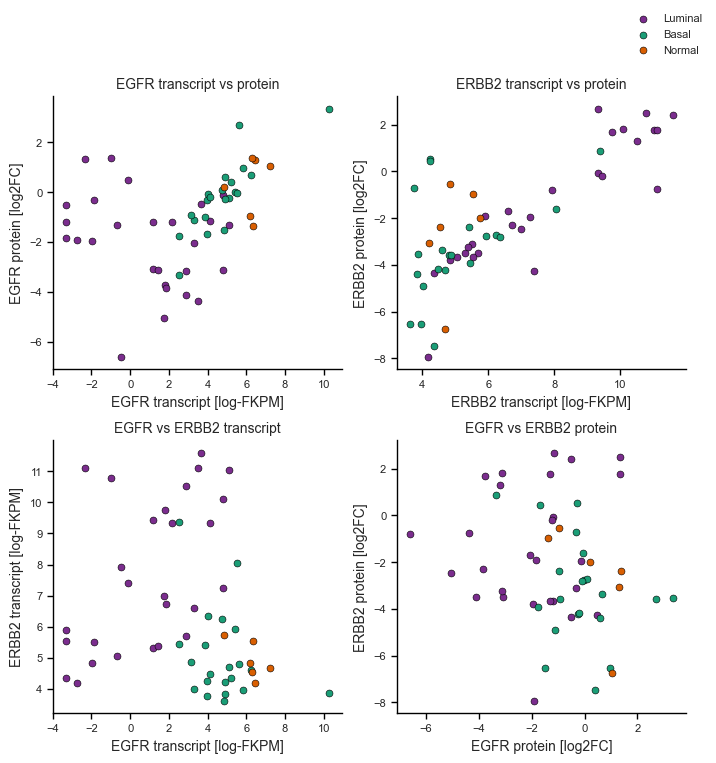

n = 54  (Luminal: 27, Basal: 21)


In [15]:

# ── 4-panel: EGFR / ERBB2 transcript × protein comparison ───────────────────
from scipy import stats

# Load all four data series
tegfr  = load_marker_data("EGFR",  "transcriptomics")
pegfr  = load_marker_data("EGFR",  "proteomics")
terbb2 = load_marker_data("ERBB2", "transcriptomics")
perbb2 = load_marker_data("ERBB2", "proteomics")

# One luminal/basal label per cell line
subtype_map = (
    pca_embedding_df
    .reset_index()
    .drop_duplicates(subset="cell_line")
    .set_index("cell_line")["luminalbasal"]
)

# Joint DataFrame – inner join all four + subtype
rtk_df = (
    pd.DataFrame({
        "EGFR_tx":    tegfr,
        "EGFR_prot":  pegfr,
        "ERBB2_tx":   terbb2,
        "ERBB2_prot": perbb2,
    })
    .join(subtype_map.rename("subtype"), how="inner")
    .dropna()
)

def _pearson_r(x, y):
    r, _ = stats.pearsonr(x, y)
    return r

# (x_col, y_col, xlabel, ylabel, title)
_panels = [
    ("EGFR_tx",   "EGFR_prot",  "EGFR transcript [log-FKPM]",  "EGFR protein [log2FC]",     "EGFR transcript vs protein"),
    ("ERBB2_tx",  "ERBB2_prot", "ERBB2 transcript [log-FKPM]", "ERBB2 protein [log2FC]",    "ERBB2 transcript vs protein"),
    ("EGFR_tx",   "ERBB2_tx",   "EGFR transcript [log-FKPM]",  "ERBB2 transcript [log-FKPM]", "EGFR vs ERBB2 transcript"),
    ("EGFR_prot", "ERBB2_prot", "EGFR protein [log2FC]",     "ERBB2 protein [log2FC]",    "EGFR vs ERBB2 protein"),
]

fig_rtk, axes_rtk = plt.subplots(2, 2, figsize=(7, 7))

for ax, (xcol, ycol, xlabel, ylabel, ptitle) in zip(axes_rtk.flat, _panels):
    for lb, color in EMBEDDING_COLORS.items():
        m = rtk_df["subtype"] == lb
        ax.scatter(
            rtk_df.loc[m, xcol], rtk_df.loc[m, ycol],
            c=color, label=lb, s=25,
            edgecolors="black", linewidths=0.4, zorder=3,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(ptitle)
    configure_axis_spines(ax)
    ax.grid(False)

# Shared legend
_h, _l = axes_rtk.flat[0].get_legend_handles_labels()
fig_rtk.legend(_h, _l, frameon=False, fontsize=8,
               loc="lower right", bbox_to_anchor=(1.02, 1.0))

fig_rtk.tight_layout()
plt.savefig("fig2_rtk_transcript_protein.pdf", bbox_inches="tight")
plt.show()
print(f"n = {len(rtk_df)}  (Luminal: {(rtk_df['subtype']=='Luminal').sum()}, "
      f"Basal: {(rtk_df['subtype']=='Basal').sum()})")


**Figure S6 | RTK transcript and protein expression across breast cancer cell lines.** Pairwise scatter plots comparing EGFR and ERBB2 expression at the transcript (log-FKPM, RNA-seq) and protein (log₂FC, mass spectrometry) levels across *n* = 56 breast cancer cell lines (Luminal, *n* = 28; Basal, *n* = 22). (**Top left**) EGFR transcript versus EGFR protein abundance; note the weak overall correlation, consistent with post-transcriptional regulation of EGFR levels. (**Top right**) ERBB2 transcript versus ERBB2 protein abundance; a stronger positive correlation is observed, with luminal cell lines showing predominantly high ERBB2 expression. (**Bottom left**) EGFR versus ERBB2 transcript levels; the two receptors are largely anti-correlated, reflecting the known EGFR-high/ERBB2-low basal versus EGFR-low/ERBB2-high luminal expression pattern. (**Bottom right**) EGFR versus ERBB2 protein levels; the anti-correlation is maintained at the protein level. Points are coloured by luminal (purple) and basal (teal) subtype. Protein levels are expressed as log₂ fold-change relative to the cross-cell-line mean.

In [16]:
rtk_df[(rtk_df.EGFR_tx < 2) & (rtk_df.EGFR_prot > -2)]

,EGFR_tx,EGFR_prot,ERBB2_tx,ERBB2_prot,subtype
cBT483,-0.095,0.478716,7.397,-4.278330,Luminal
cEFM19,-3.322,-1.833860,5.897,-1.925426,Luminal
cHCC1500,-3.322,-1.187283,5.527,-3.658330,Luminal
cLY2,-1.978,-1.947415,4.837,-3.795106,Luminal
cMCF7,-0.668,-1.310829,5.040,-3.680252,Luminal
cMDAMB134VI,-2.752,-1.925778,4.171,-7.924411,Luminal
cMDAMB415,-1.874,-0.338131,5.495,-3.115303,Luminal
cMFM223,-3.322,-0.521195,4.353,-4.350691,Luminal
cOCUBM,1.184,-1.220881,9.450,-0.190859,Luminal
cUACC812,-2.339,1.342189,11.124,1.748085,Luminal
